# Fraud Detection

Clean features from the ETL pipeline, then EDA, feature engineering, model training, and evaluation.

---

### What this notebook does

**EDA**
Looks at the class imbalance, the spread of amounts, balance patterns, and how often each account appears. It also scores the existing rule (`isflaggedfraud`) as a baseline to beat.

**Feature engineering**
Groups features by when they are available: before the payment settles (amount, type, time) vs after it settles (balance changes). See the feature-engineering cell.

**Modelling: two ways to run it**
The same four models (Logistic Regression, Random Forest, XGBoost, LightGBM) are trained for two situations:
- **Scenario A, real-time:** only what is known before the payment goes through (amount, type, time). It approves or blocks the payment on the spot.
- **Scenario B, after the transaction:** runs a bit later, once balance changes are visible, and reverses bad payments (cancel and refund).

Scenario B scores much higher, but on PaySim that gap is mostly a data quirk (the balances give away the label), so a real system would be strong but not perfect. See the appendix. We handle the class imbalance with class weights, compare models with PR-AUC, and explain both LightGBM models with SHAP.

---

> Features are loaded from the clean SQLite database (output of `01_etl_reconciliation.ipynb`).  
> The `isfraud` labels come from the raw simulation file. They were left out of the ETL pipeline because in production you do not know the label when the transaction happens.  
> The train/test split is by time: steps 1 to 550 train, 551 to 743 test.

For more on the PaySim dataset, see https://www.kaggle.com/datasets/ealaxi/paysim1, and check `DataDescription.md`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import sqlite3
import hashlib
import gc
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, precision_recall_curve,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

# Extract & Load the dataset
Features come from the clean SQLite table built in notebook 01. The `isfraud` label was deliberately left out of that table, because in real life you do not know whether a transaction is fraud at the moment it happens. We add the label back here by rebuilding `txn_id` on the raw file and joining on it.

In [2]:
def make_txn_id(df):
    hash_input = (
        df['step'].astype(str)           + '|' + df['type']                       + '|' +
        df['amount'].astype(str)         + '|' + df['nameorig']                   + '|' +
        df['oldbalanceorg'].astype(str)  + '|' + df['newbalanceorig'].astype(str) + '|' +
        df['namedest']                   + '|' + df['oldbalancedest'].astype(str) + '|' +
        df['newbalancedest'].astype(str)
    )
    return hash_input.map(lambda s: hashlib.sha256(s.encode()).hexdigest()[:16])

conn = sqlite3.connect("db/transactions.db")
df   = pd.read_sql("SELECT * FROM transactions", conn)
conn.close()

In [3]:
# read just the columns we need to rebuild txn_id
raw = pd.read_csv("data/raw/paysim.csv", usecols=[
    'step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
    'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud'
])
raw.columns = raw.columns.str.lower()
raw['txn_id'] = make_txn_id(raw)

df = df.merge(raw[['txn_id', 'isfraud']], on='txn_id', how='left')

# free this second full copy of the data from memory
del raw
gc.collect()

print(f"[INFO] {len(df)} rows loaded  |  Label coverage: {df['isfraud'].notna().mean():.4%}")
df.head()

[INFO] 6362588 rows loaded  |  Label coverage: 100.0000%


,step,type,amount,nameorig,oldbalanceorg,newbalanceorig,namedest,oldbalancedest,newbalancedest,isflaggedfraud,txn_id,isfraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1c315db8b74d6ea6,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,03e8322be1d47652,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,0,5614cdae1ae2edd8,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,0,13f1fa57ef94120d,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,fe56eae551b6f3d0,0


# Exploratory Data Analysis (EDA)

## Class imbalance 

In PaySim, fraud only happens in TRANSFER and CASH_OUT transactions. Spotting this early helps us pick good features and the right way to measure the model.

[INFO] Overall fraud rate: 0.1286%



          fraud_count  fraud_rate    total
type                                      
CASH_OUT         4100    0.001832  2237484
TRANSFER         4081    0.007658   532893
CASH_IN             0    0.000000  1399284
DEBIT               0    0.000000    41432
PAYMENT             0    0.000000  2151495


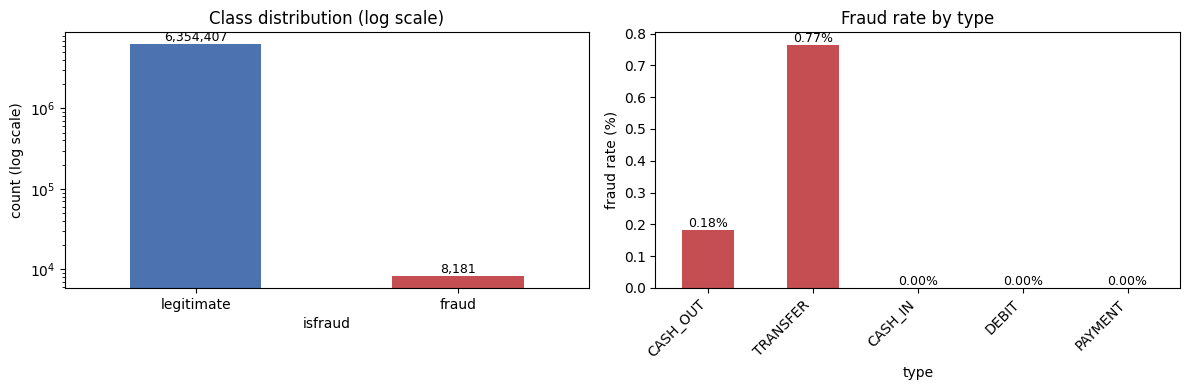

In [4]:
print(f"[INFO] Overall fraud rate: {df['isfraud'].mean():.4%}\n")

fraud_by_type = (
    df.groupby('type')['isfraud']
    .agg(fraud_count='sum', fraud_rate='mean', total='count')
    .sort_values('fraud_count', ascending=False)
)
print(fraud_by_type)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# fraud is so rare that I use a log y-axis to make the differences more visible
counts = df['isfraud'].value_counts().sort_index()
counts.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52'],
            title='Class distribution (log scale)')
axes[0].set_yscale('log')
axes[0].set_xticklabels(['legitimate', 'fraud'], rotation=0)
axes[0].set_ylabel('count (log scale)')
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# the share of each transaction type that is fraud, shown as a percentage.
(fraud_by_type['fraud_rate'] * 100).plot(kind='bar', ax=axes[1], color='#C44E52',
                                         title='Fraud rate by type')
axes[1].set_ylabel('fraud rate (%)')
axes[1].set_xticklabels(fraud_by_type.index, rotation=45, ha='right')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}%",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Left**: How many legit vs fraud rows. Fraud is so rare that we use a log y-axis,
otherwise its bar is invisible. Counts are printed on top of each bar.

**Right**: The share of each transaction type that is fraud, shown as a percentage.

## Amount distributions

Transaction amounts are very skewed: most are small, but a few transfers reach about 90 million. Essentially, two plots shows the amount distribution in different ways. A normal axis will show just one bar skewed to the left, so we use a log scale (log(1 + amount)), which spreads out the small values and shortens the tail. The histogram (right) is normalized to a density per class, so the much smaller fraud group is still visible next to the huge legitimate group.

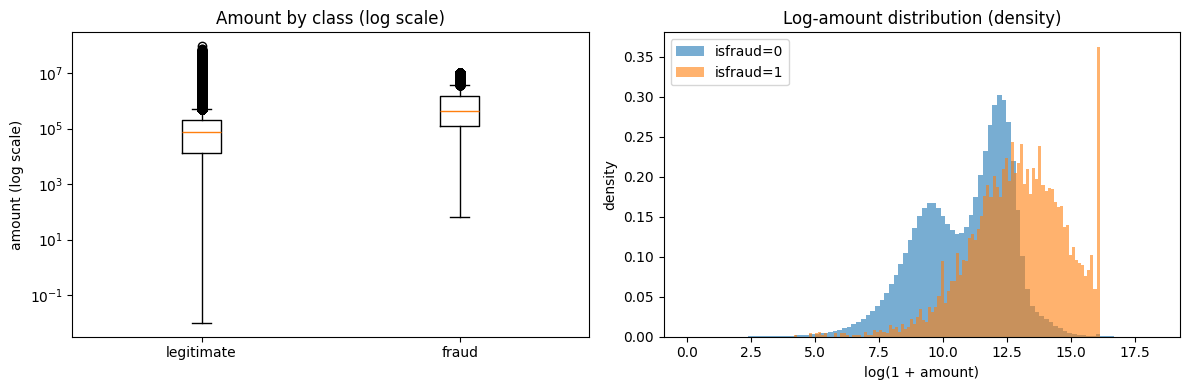

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# amount distribution by class
# fraud is so rare that i use a log y-axis to make the differences more visible
legit_amt = df.loc[df['isfraud'] == 0, 'amount']
fraud_amt = df.loc[df['isfraud'] == 1, 'amount']
axes[0].boxplot([legit_amt, fraud_amt], labels=['legitimate', 'fraud'], showfliers=True)
axes[0].set_yscale('log')
axes[0].set_title('Amount by class (log scale)')
axes[0].set_ylabel('amount (log scale)')

# y axis is density, shows how densely the amounts are distributed
for label, group in df.groupby('isfraud'):
    axes[1].hist(np.log1p(group['amount']), bins=100, alpha=0.6,
                 density=True, label=f'isfraud={int(label)}')
axes[1].set_title('Log-amount distribution (density)')
axes[1].set_xlabel('log(1 + amount)')
axes[1].set_ylabel('density')
axes[1].legend()

plt.tight_layout()
plt.show()

**Left**: Box plot on a log axis. Shows that fraud transaction amounts are generally higher than legitimate ones.

**Right**: Log-amount histogram, scaled to a density per class so the shapes are comparable.
It shows the shape of the distribution, normalized so that the area under the curve is 1. This allows us to compare distributions even if they have different total counts.

## Balance analysis
Fraud transfers tend to empty the sender's account and move the money into accounts that started at zero (a money-mule pattern).

Balances range from tiny to huge, so we plot `log(1 + balance)` to show a readable range. Each line is scaled to a density per class, so the rare fraud group stays visible.

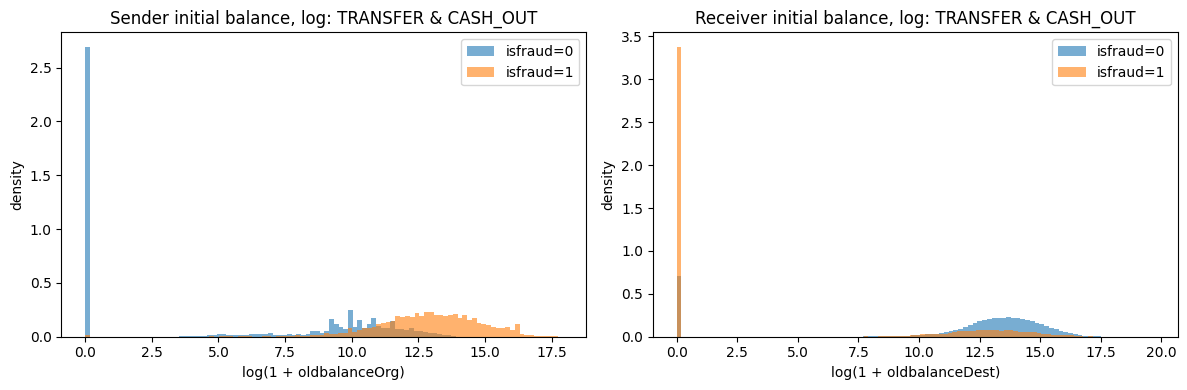

In [6]:
risk_df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, group in risk_df.groupby('isfraud'):
    axes[0].hist(np.log1p(group['oldbalanceorg']),  bins=100, alpha=0.6,
                 density=True, label=f'isfraud={int(label)}')
    axes[1].hist(np.log1p(group['oldbalancedest']), bins=100, alpha=0.6,
                 density=True, label=f'isfraud={int(label)}')
axes[0].set_title('Sender initial balance, log: TRANSFER & CASH_OUT')
axes[1].set_title('Receiver initial balance, log: TRANSFER & CASH_OUT')
axes[0].set_xlabel('log(1 + oldbalanceOrg)')
axes[0].set_ylabel('density')
axes[1].set_xlabel('log(1 + oldbalanceDest)')
axes[1].set_ylabel('density')
for ax in axes: ax.legend()
plt.tight_layout()
plt.show()

The patterns above suggest that fraudsters often transfer out large amounts from accounts with high initial balance, and the receivers of these transfers very often have zero initial balance. This is consistent with a common fraud pattern where fraudsters compromise accounts with higher balance, then quickly transfer out large sums to other accounts (often mule accounts) before the fraud is detected.

## Rule-based fraud detection system baseline:

An illegal attempt in this dataset is an attempt to transfer more than 200000 in a single transaction. (DataDescription.MD)
Lets evaluate isflaggedfraud against ground truth on the raw pre-ETL dataset.
Establishes the performance floor our ML model should exceed.

In [7]:
raw_eval = pd.read_csv("data/raw/paysim.csv", usecols=['isFraud', 'isFlaggedFraud'])
raw_eval.columns = raw_eval.columns.str.lower()

print("[INFO] Rule-based system (isflaggedfraud vs isfraud):")
print(f"  Precision : {precision_score(raw_eval['isfraud'], raw_eval['isflaggedfraud']):.4f}")
print(f"  Recall    : {recall_score(raw_eval['isfraud'], raw_eval['isflaggedfraud']):.4f}")
print(f"  F1        : {f1_score(raw_eval['isfraud'], raw_eval['isflaggedfraud']):.4f}")
print(f"  Flagged   : {raw_eval['isflaggedfraud'].sum()}  |  Actual fraud: {raw_eval['isfraud'].sum()}")


[INFO] Rule-based system (isflaggedfraud vs isfraud):


  Precision : 1.0000


  Recall    : 0.0019


  F1        : 0.0039
  Flagged   : 16  |  Actual fraud: 8213


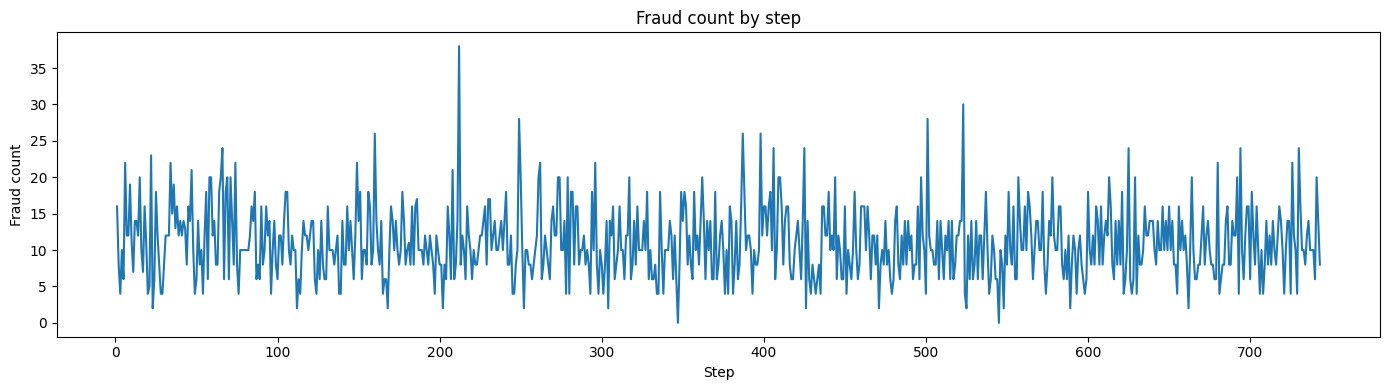

In [8]:
# how fraud counts change over time

fraud_by_step = df.groupby('step')['isfraud'].sum()

plt.figure(figsize=(14, 4))
fraud_by_step.plot()
plt.title('Fraud count by step')
plt.xlabel('Step')
plt.ylabel('Fraud count')
plt.tight_layout()
plt.show()


Here, there seems to be no visible pattern.

## How often each account appears
Accounts that commit fraud almost always show up just once in PaySim.

In [9]:
orig_counts       = df.groupby('nameorig').size()
fraud_orig_counts = df[df['isfraud'] == 1].groupby('nameorig').size()

print(f"[INFO] Median transactions per originator (all)   : {orig_counts.median():.0f}")
print(f"[INFO] Median transactions per originator (fraud) : {fraud_orig_counts.median():.0f}")


[INFO] Median transactions per originator (all)   : 1
[INFO] Median transactions per originator (fraud) : 1


# Feature Engineering

We build two sets of features, one for each way the model could be used. The split is about timing: what does the model know at the moment it has to decide?

- **Scenario A, real-time (before the payment goes through).** Only things we know up front: the **amount**, the **transaction type**, and the **time** (hour of day, day of week). A model that approves or blocks a payment on the spot cannot use anything else. (The sender's starting balance, `oldbalanceOrg`, is technically known here too, but we leave it out: the appendix shows that on PaySim it basically gives away the answer instead of being a real signal.)
- **Scenario B, after the transaction (clawback).** The payment already went through, so now we can also see how the balances moved: differences, accounting mismatches, and "account emptied" flags. A model running a bit later can use these to flag a payment and reverse it (cancel and refund).

**A warning about the Scenario B numbers.** On PaySim, the after-the-fact balance features predict fraud almost perfectly, but mostly because the simulator creates fraud by emptying the account. So these columns are really just re-describing the label, not finding a pattern that would carry over to real data (the appendix measures this). The two-scenario split makes it fair to *use* these features at that stage; it does not make the near-perfect score realistic.

In [10]:
# drop columns we no longer need for modelling
# for memory efficiency
df = df.drop(columns=['nameorig', 'namedest', 'txn_id', 'isflaggedfraud'], errors='ignore')
gc.collect()

df['type'] = df['type'].astype('category')

# real-time features: known BEFORE the payment goes through.
df['amount_log']        = np.log1p(df['amount'])
df['hour']              = df['step'] % 24            # hour of day 
df['day_of_week']      = (df['step'] // 24) % 7      # raw step converted to day of week (0-6)
df['is_high_risk_type'] = df['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)
df['type_encoded']      = df['type'].cat.codes        # number version of 'type' for the sklearn models

# post-transaction features: balance changes, known only AFTER the payment settles
df['amount_to_orig_bal'] = df['amount'] / (df['oldbalanceorg'] + 1)
df['orig_balance_delta'] = df['newbalanceorig']  - df['oldbalanceorg']
df['dest_balance_delta'] = df['newbalancedest']  - df['oldbalancedest']
df['orig_balance_error'] = (df['oldbalanceorg']  - df['amount'] - df['newbalanceorig']).abs()
df['dest_balance_error'] = (df['oldbalancedest'] + df['amount'] - df['newbalancedest']).abs()
df['orig_drained']       = (df['newbalanceorig']  == 0).astype(int)
df['dest_was_empty']     = (df['oldbalancedest']  == 0).astype(int)

# Scenario A (real-time) uses the pre-payment features only.
# Scenario B (after the transaction) uses Scenario A plus the balance-change features.
# LightGBM can take type as a category directly; the sklearn models use the number version.
features_lgb_realtime = [
    'amount', 'amount_log',
    'hour', 'day_of_week',
    'is_high_risk_type',
    'type',
]
balance_feats = [
    'amount_to_orig_bal',
    'orig_balance_delta', 'dest_balance_delta',
    'orig_balance_error', 'dest_balance_error',
    'orig_drained', 'dest_was_empty',
]
features_lgb_posttxn = features_lgb_realtime + balance_feats

features_sk_realtime = [f for f in features_lgb_realtime if f != 'type'] + ['type_encoded']
features_sk_posttxn  = [f for f in features_lgb_posttxn  if f != 'type'] + ['type_encoded']

print(f"[INFO] Real-time features ({len(features_lgb_realtime)}): {features_lgb_realtime}")
print(f"[INFO] Post-txn   features ({len(features_lgb_posttxn)}): {features_lgb_posttxn}")

[INFO] Real-time features (6): ['amount', 'amount_log', 'hour', 'day_of_week', 'is_high_risk_type', 'type']
[INFO] Post-txn   features (13): ['amount', 'amount_log', 'hour', 'day_of_week', 'is_high_risk_type', 'type', 'amount_to_orig_bal', 'orig_balance_delta', 'dest_balance_delta', 'orig_balance_error', 'dest_balance_error', 'orig_drained', 'dest_was_empty']


# Train / Test split

We split by time: train on the earlier steps, test on the later ones. This copies real life, where you train on the past and run on the future.

We set `SPLIT_STEP` to 550 (down from 630) so the test set is bigger. The first version left only about 89k test rows, because PaySim has fewer transactions near the end. A wider window gives a steadier score.

Why not other options:
- **k-fold cross-validation** mixes future rows into training, which leaks time, so we skip it here.

In [11]:
# split by time SPLIT_STEP is the last training step
# every row after it is the test set.
SPLIT_STEP = 550
train_mask = df['step'] <= SPLIT_STEP

y_train = df.loc[train_mask,  'isfraud']
y_test  = df.loc[~train_mask, 'isfraud']


def make_matrices(features_lgb, features_sk):
    """Build train/test tables for one feature set.
    Returns the LightGBM tables (with 'type' as a category), the sklearn tables,
    and scaled sklearn arrays. The scaler is fit on the training rows only."""
    Xtr_lgb = df.loc[train_mask,  features_lgb]
    Xte_lgb = df.loc[~train_mask, features_lgb]
    Xtr_sk  = df.loc[train_mask,  features_sk]
    Xte_sk  = df.loc[~train_mask, features_sk]
    scaler  = StandardScaler()
    Xtr_sc  = scaler.fit_transform(Xtr_sk)
    Xte_sc  = scaler.transform(Xte_sk)
    return Xtr_lgb, Xte_lgb, Xtr_sk, Xte_sk, Xtr_sc, Xte_sc


# Scenario A (real-time) tables. also reuse these later for the confusion
# matrix and SHAP.
X_train_lgb, X_test_lgb, X_train_sk, X_test_sk, X_train_scaled, X_test_scaled = \
    make_matrices(features_lgb_realtime, features_sk_realtime)

print(f"[INFO] Train: {int(train_mask.sum())} rows  |  Test: {int((~train_mask).sum())} rows")
print(f"[INFO] Train fraud rate: {y_train.mean():.4%}  |  Test fraud rate: {y_test.mean():.4%}")

[INFO] Train: 6166007 rows  |  Test: 196581 rows
[INFO] Train fraud rate: 0.0982%  |  Test fraud rate: 1.0825%


# Models

Handling the class imbalance: we tell each model to weight the rare fraud class more heavily. For the sklearn models and LightGBM that is `class_weight='balanced'`; for XGBoost it is `scale_pos_weight` (the ratio of legit to fraud).

**Why weighting and not SMOTE.** SMOTE balances the classes by inventing synthetic fraud rows. We avoid it here because:
- With about 6M rows and mostly category-style features, the made-up rows do not look like real transactions, and it is slow and memory-heavy.
- Most importantly, SMOTE only fixes the balance inside the training set. It does not fix the fact that the fraud rate is higher in our test period than in our training period. That gap is better handled by choosing a good decision threshold, which we do below.

In [12]:
neg_pos_ratio = (y_train == 0).sum() / y_train.sum()


def build_models(Xtr_sk, Xte_sk, Xtr_sc, Xte_sc, Xtr_lgb, Xte_lgb):
    """Set up the four models for one feature set's tables."""
    return {
        'Logistic Regression': (
            LogisticRegression(class_weight='balanced', max_iter=1000),
            Xtr_sc, Xte_sc),
        'Random Forest': (
            RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42),
            Xtr_sk, Xte_sk),
        'XGBoost': (
            xgb.XGBClassifier(n_estimators=200, scale_pos_weight=neg_pos_ratio, eval_metric='aucpr', random_state=42),
            Xtr_sk, Xte_sk),
        'LightGBM': (
            lgb.LGBMClassifier(n_estimators=200, class_weight='balanced', random_state=42),
            Xtr_lgb, Xte_lgb),
    }


def run_suite(models, verbose=True):
    """train each model, score it on the test set, and collect the results.
    PR-AUC here is the average precision, the standard way to summarise a
    precision-recall curve when one class is rare"""
    results, pr_curves = {}, {}
    for name, (model, X_tr, X_te) in models.items():
        fit_kwargs = {'categorical_feature': ['type']} if name == 'LightGBM' else {}
        model.fit(X_tr, y_train, **fit_kwargs)

        proba = model.predict_proba(X_te)[:, 1]
        preds = model.predict(X_te)

        prec, rec, _ = precision_recall_curve(y_test, proba)   # used for the PR curve plot
        pr_auc = average_precision_score(y_test, proba)        # single-number summary

        pr_curves[name] = (prec, rec, pr_auc)
        results[name]   = {'model': model, 'proba': proba, 'preds': preds, 'pr_auc': pr_auc}

        if verbose:
            print(f"\n[{name}]  PR-AUC: {pr_auc:.4f}")
            print(classification_report(y_test, preds, target_names=['legitimate', 'fraud']))
    return results, pr_curves


# Scenario A: real-time. Pre-payment features only.
print("=" * 60)
print("SCENARIO A: REAL-TIME (before the payment settles)")
print("=" * 60)
results, pr_curves = run_suite(
    build_models(X_train_sk, X_test_sk, X_train_scaled, X_test_scaled, X_train_lgb, X_test_lgb)
)

SCENARIO A: REAL-TIME (before the payment settles)



[Logistic Regression]  PR-AUC: 0.1932
              precision    recall  f1-score   support

  legitimate       1.00      0.79      0.88    194453
       fraud       0.04      0.88      0.08      2128

    accuracy                           0.79    196581
   macro avg       0.52      0.83      0.48    196581
weighted avg       0.99      0.79      0.87    196581




[Random Forest]  PR-AUC: 0.3254
              precision    recall  f1-score   support

  legitimate       0.99      1.00      0.99    194453
       fraud       0.42      0.32      0.36      2128

    accuracy                           0.99    196581
   macro avg       0.71      0.66      0.68    196581
weighted avg       0.99      0.99      0.99    196581




[XGBoost]  PR-AUC: 0.3697
              precision    recall  f1-score   support

  legitimate       1.00      0.90      0.95    194453
       fraud       0.07      0.69      0.13      2128

    accuracy                           0.90    196581
   macro avg       0.53      0.80      0.54    196581
weighted avg       0.99      0.90      0.94    196581



[LightGBM] [Info] Number of positive: 6053, number of negative: 6159954
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045584 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 6166007, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000



[LightGBM]  PR-AUC: 0.4533
              precision    recall  f1-score   support

  legitimate       1.00      0.88      0.93    194453
       fraud       0.07      0.84      0.13      2128

    accuracy                           0.88    196581
   macro avg       0.53      0.86      0.53    196581
weighted avg       0.99      0.88      0.93    196581



## Scenario B: after the transaction (clawback)

The same four models, now also using the balance-change features that only exist once the payment has gone through. This is a real way to run a fraud check: not a real-time gate, but a check that runs a bit later and flags a finished payment so it can be reversed (cancel and refund).

The PR-AUC jumps way up. But on PaySim, most of that near-perfect score is the simulator giving away the answer through the balances, very likely not a pattern that would hold on real data. The idea of checking after the fact is real, the near-perfect score is not.

In [13]:
# Scenario B: after the transaction. 
# adds the balance features that only exist once the payment settles

# free Scenario A things we don't reuse, so we don't hold two big model sets at once
for _name in list(results):
    if _name != 'LightGBM':
        results[_name]['model'] = None
for _v in ['X_train_scaled', 'X_test_scaled']:
    globals().pop(_v, None)
gc.collect()

Xb_train_lgb, Xb_test_lgb, Xb_train_sk, Xb_test_sk, Xb_train_sc, Xb_test_sc = \
    make_matrices(features_lgb_posttxn, features_sk_posttxn)

print("=" * 60)
print("SCENARIO B: AFTER THE TRANSACTION (balance features added)")
print("=" * 60)
results_posttxn, pr_curves_posttxn = run_suite(
    build_models(Xb_train_sk, Xb_test_sk, Xb_train_sc, Xb_test_sc, Xb_train_lgb, Xb_test_lgb)
)

SCENARIO B: AFTER THE TRANSACTION (balance features added)



[Logistic Regression]  PR-AUC: 0.9435
              precision    recall  f1-score   support

  legitimate       1.00      0.99      0.99    194453
       fraud       0.48      1.00      0.64      2128

    accuracy                           0.99    196581
   macro avg       0.74      0.99      0.82    196581
weighted avg       0.99      0.99      0.99    196581




[Random Forest]  PR-AUC: 1.0000
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00    194453
       fraud       1.00      1.00      1.00      2128

    accuracy                           1.00    196581
   macro avg       1.00      1.00      1.00    196581
weighted avg       1.00      1.00      1.00    196581




[XGBoost]  PR-AUC: 1.0000
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00    194453
       fraud       1.00      1.00      1.00      2128

    accuracy                           1.00    196581
   macro avg       1.00      1.00      1.00    196581
weighted avg       1.00      1.00      1.00    196581



[LightGBM] [Info] Number of positive: 6053, number of negative: 6159954


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053599 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1827
[LightGBM] [Info] Number of data points in the train set: 6166007, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000



[LightGBM]  PR-AUC: 1.0000
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00    194453
       fraud       1.00      1.00      1.00      2128

    accuracy                           1.00    196581
   macro avg       1.00      1.00      1.00    196581
weighted avg       1.00      1.00      1.00    196581



In [14]:
# side by side: real-time vs after-the-transaction PR-AUC for each model.
comparison = pd.DataFrame({
    'PR_AUC_realtime': {k: v['pr_auc'] for k, v in results.items()},
    'PR_AUC_posttxn' : {k: v['pr_auc'] for k, v in results_posttxn.items()},
})
comparison['posttxn_uplift'] = comparison['PR_AUC_posttxn'] - comparison['PR_AUC_realtime']
comparison = comparison.sort_values('PR_AUC_realtime', ascending=False)
print(comparison.round(4))

                     PR_AUC_realtime  PR_AUC_posttxn  posttxn_uplift
LightGBM                      0.4533          1.0000          0.5467
XGBoost                       0.3697          1.0000          0.6303
Random Forest                 0.3254          1.0000          0.6746
Logistic Regression           0.1932          0.9435          0.7503


## Takeaway: two ways to run the model

- **Real-time (Scenario A)** is the honest production number: PR-AUC around 0.19 to 0.45 using only amount, type, and time. It still does far better than the existing rule in the data, which catches just 0.2% of fraud. LightGBM catches most of the fraud, but with low precision at the default cutoff, so you would tune the cutoff to trade off missed fraud against false alarms.
- **After the transaction (Scenario B)** is genuinely stronger: once the balances move, "this account was just emptied" is visible, and you can act on it by reversing the payment. But its near-perfect PaySim score is too good to be true, because the simulator builds fraud by emptying the account, so the balance columns are basically re-stating the label (see the appendix). 
On real data, after-the-fact checks is better yes, but not this perfect.

# Precision-Recall curves

PR-AUC (average precision) is our main score. It is more useful than ROC-AUC when one class is very rare. Solid lines are real-time (Scenario A); dashed lines are after-the-transaction (Scenario B).

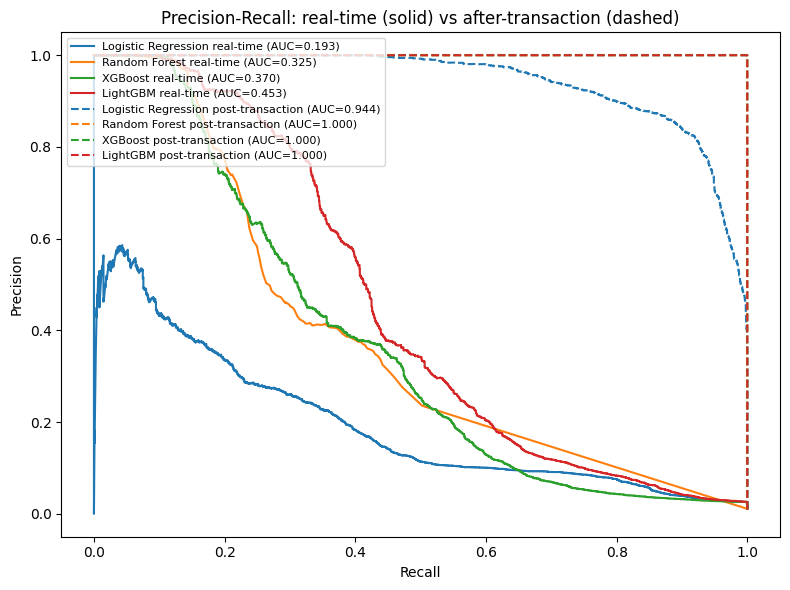

In [15]:
plt.figure(figsize=(8, 6))

# real-time = solid lines, after-the-transaction = dashed
line_color = {}
for name, (prec, rec, pr_auc) in pr_curves.items():
    line, = plt.plot(rec, prec, label=f"{name} real-time (AUC={pr_auc:.3f})")
    line_color[name] = line.get_color()
for name, (prec, rec, pr_auc) in pr_curves_posttxn.items():
    plt.plot(rec, prec, linestyle='--', color=line_color.get(name),
             label=f"{name} post-transaction (AUC={pr_auc:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall: real-time (solid) vs after-transaction (dashed)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Choosing a decision cutoff

By default a model calls anything above probability 0.5 "fraud," but 0.5 is rarely the best choice when fraud is rare. Below we find the cutoff that gives the best F1 (a balance of precision and recall) for the real-time LightGBM model, and show the trade-off. In a real system you would pick this cutoff from the cost of a missed fraud versus the cost of a false alarm.

In [16]:
# real-time lightgbm: default 0.5 cutoff vs the cutoff that gives the best F1.
prec, rec, thr = precision_recall_curve(y_test, results['LightGBM']['proba'])
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best = f1[:-1].argmax()          # the last precision/recall point has no threshold
best_thr = thr[best]

proba_a = results['LightGBM']['proba']
print("Scenario A (real-time) LightGBM:")
print(f"  cutoff 0.50      ->  precision {precision_score(y_test, proba_a >= 0.5):.3f}, "
      f"recall {recall_score(y_test, proba_a >= 0.5):.3f}, "
      f"F1 {f1_score(y_test, proba_a >= 0.5):.3f}")
print(f"  cutoff {best_thr:.2f} (best F1)  ->  precision {prec[best]:.3f}, "
      f"recall {rec[best]:.3f}, F1 {f1[best]:.3f}")

Scenario A (real-time) LightGBM:
  cutoff 0.50      ->  precision 0.070, recall 0.836, F1 0.129
  cutoff 0.99 (best F1)  ->  precision 0.578, recall 0.396, F1 0.470


# Confusion matrices

Counts of right and wrong predictions at the 0.5 cutoff, for both scenarios. Real-time (Scenario A) misses more fraud and raises more false alarms. After-the-transaction (Scenario B) is near-perfect on PaySim, for the inflated reasons explained above.

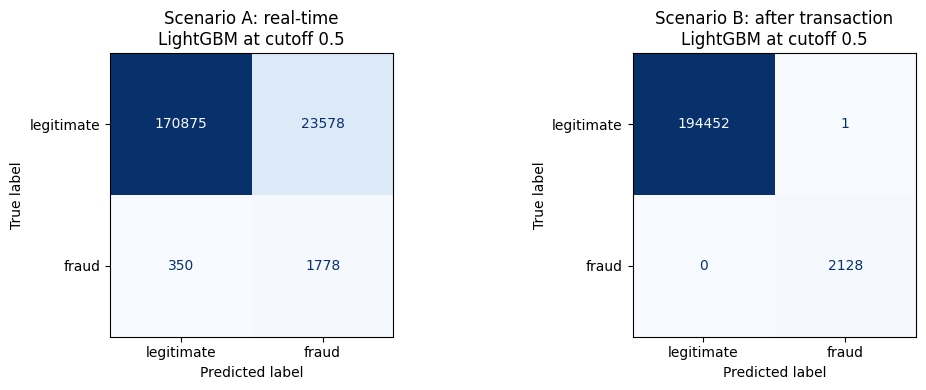

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
panels = [
    ('Scenario A: real-time',         results),
    ('Scenario B: after transaction', results_posttxn),
]
for ax, (title, res) in zip(axes, panels):
    preds = (res['LightGBM']['proba'] >= 0.5).astype(int)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, preds),
        display_labels=['legitimate', 'fraud'],
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{title}\nLightGBM at cutoff 0.5")
plt.tight_layout()
plt.show()

# SHAP: what drives the predictions

SHAP shows how much each feature pushes a prediction toward "fraud" or "legitimate," and in which direction. We look at both scenarios on a 5,000-row sample (the picture is stable at that size). Watch how the important features change: real-time leans on transaction type and amount, while after-the-transaction leans on the balance-change features (which is exactly the PaySim quirk from the appendix).

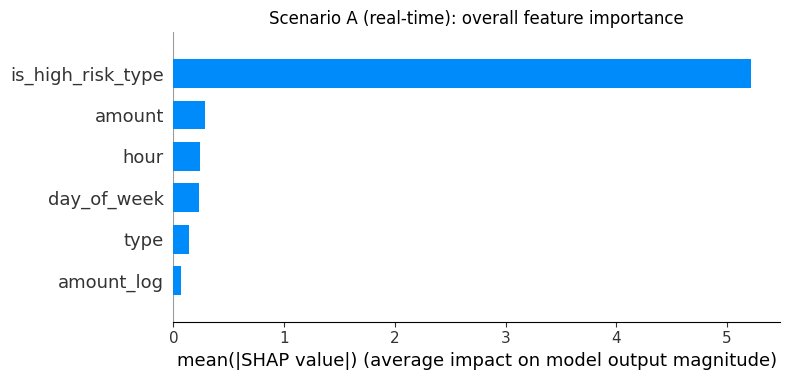

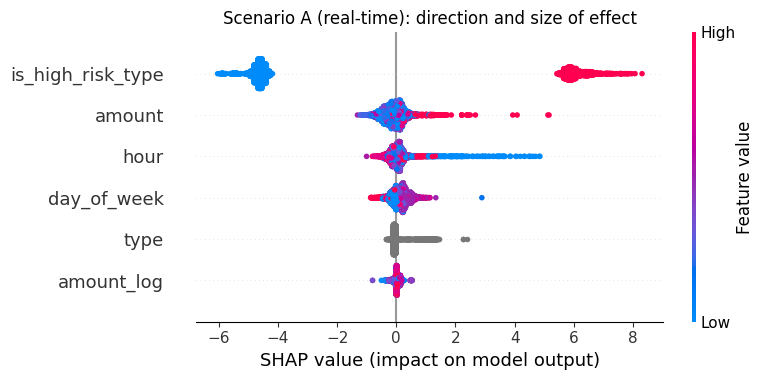

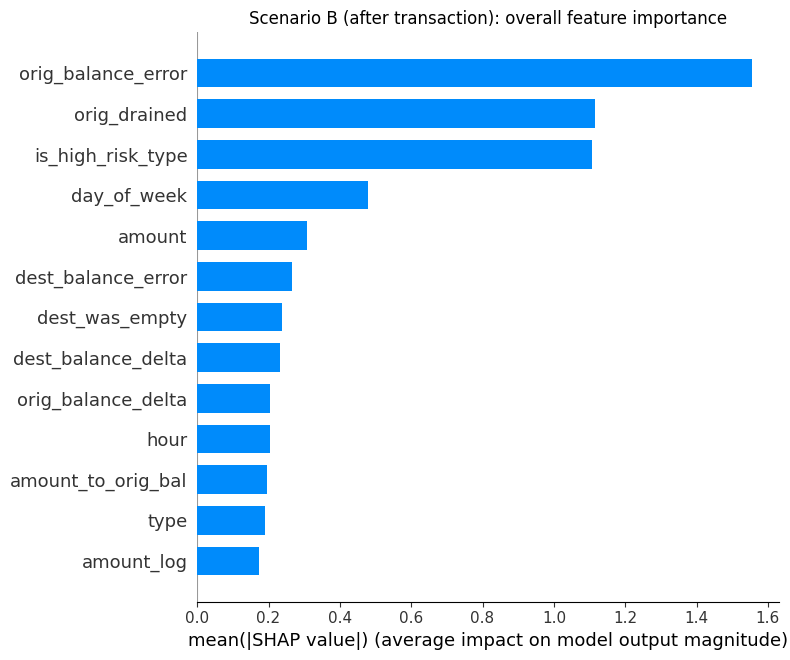

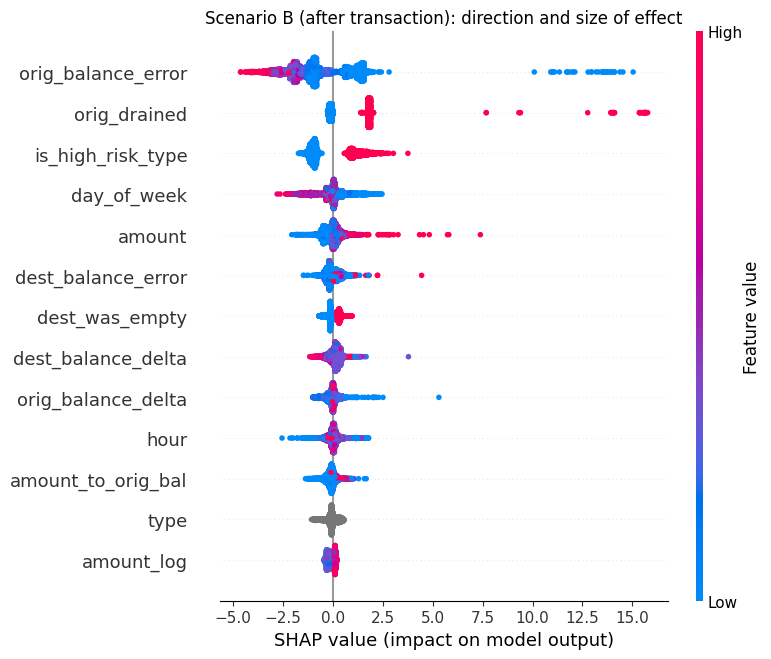

In [18]:
def shap_summary(model, X_sample, title):
    """Two SHAP plots for one model: overall importance, then effect direction."""
    explainer = shap.TreeExplainer(model)
    vals = explainer.shap_values(X_sample)
    vals = vals[1] if isinstance(vals, list) else vals   # pick the fraud class if a list is returned

    shap.summary_plot(vals, X_sample, plot_type='bar', show=False)
    plt.title(f"{title}: overall feature importance")
    plt.tight_layout(); plt.show()

    shap.summary_plot(vals, X_sample, show=False)
    plt.title(f"{title}: direction and size of effect")
    plt.tight_layout(); plt.show()


# scenario A
shap_summary(results['LightGBM']['model'],
             X_test_lgb.sample(5000, random_state=42),
             "Scenario A (real-time)")

# scenario B
shap_summary(results_posttxn['LightGBM']['model'],
             Xb_test_lgb.sample(5000, random_state=42),
             "Scenario B (after transaction)")

# Appendix: how much of the Scenario B near-perfect score is real?

Scenario B relies on balance features that only exist after the payment settles. 
Using them at that stage is fair on timing. 
But how much of their power is a real pattern, and how much is just a effect of how Paysim was built? Here we dig into that, focusing on the starting balances (`oldbalanceOrg`, `oldbalanceDest`), the part that is hardest to dismiss.

There are two different ways a feature can "cheat":
- **Timing:** is the value known before the outcome? After the transaction, the balances are fine on this point.
- **How the data was made:** does the feature just re-describe how the labels were created? On PaySim, yes: the simulator makes fraud by emptying the account, and it records the receiver's balance oddly for fraud.

The cells below measure both: first how strongly each column separates fraud from legit, then what happens to PR-AUC when we add them back to the real-time model.

In [19]:
# how strongly does each balance column separate fraud from legit and why
fraud = df['isfraud'] == 1
legit = df['isfraud'] == 0
risk  = df['type'].isin(['TRANSFER', 'CASH_OUT'])

# empties the account exactly: amount equals the starting balance
# known before the payment
df['drains_full_bal'] = (
    ((df['oldbalanceorg'] - df['amount']).abs() < 0.01) & (df['oldbalanceorg'] > 0)
).astype(int)

def share(mask, cond):
    return 100 * (cond & mask).sum() / mask.sum()

diag = pd.DataFrame(
    {
        'fraud %': [
            share(fraud,        df['oldbalancedest'] == 0),
            share(fraud & risk, df['oldbalancedest'] == 0),
            share(fraud,        df['oldbalanceorg'] == 0),
            share(fraud,        df['drains_full_bal'] == 1),
        ],
        'legit %': [
            share(legit,        df['oldbalancedest'] == 0),
            share(legit & risk, df['oldbalancedest'] == 0),
            share(legit,        df['oldbalanceorg'] == 0),
            share(legit,        df['drains_full_bal'] == 1),
        ],
    },
    index=[
        'oldbalancedest == 0',
        'oldbalancedest == 0  (TRANSFER/CASH_OUT only)',
        'oldbalanceorg == 0',
        'amount == oldbalanceorg  (empties the account)',
    ],
)
print(diag.round(2))

                                                fraud %  legit %
oldbalancedest == 0                               65.14    42.48
oldbalancedest == 0  (TRANSFER/CASH_OUT only)     65.14    13.90
oldbalanceorg == 0                                 0.31    33.09
amount == oldbalanceorg  (empties the account)    97.89     0.00


In [20]:
# same time-based split, LightGBM only. we add the starting-balance columns back
# to the real-time set, one step at a time, and watch PR-AUC.
probe_sets = {
    'A  real-time (amount/type/time)'       : features_lgb_realtime,
    'C1 + oldbalanceorg'                    : features_lgb_realtime + ['oldbalanceorg'],
    'C2 + oldbalanceorg + oldbalancedest'   : features_lgb_realtime + ['oldbalanceorg', 'oldbalancedest'],
    'C3 + amount_to_orig_bal + drains_full' : features_lgb_realtime + ['amount_to_orig_bal', 'drains_full_bal'],
}

probe = {}
for name, feats in probe_sets.items():
    m = lgb.LGBMClassifier(n_estimators=200, class_weight='balanced',
                           random_state=42, verbose=-1)
    m.fit(df.loc[train_mask, feats], y_train, categorical_feature=['type'])
    proba = m.predict_proba(df.loc[~train_mask, feats])[:, 1]
    probe[name] = average_precision_score(y_test, proba)

probe_df = pd.DataFrame.from_dict(probe, orient='index', columns=['PR_AUC']).round(4)
print(probe_df)

                                       PR_AUC
A  real-time (amount/type/time)        0.4533
C1 + oldbalanceorg                     0.9614
C2 + oldbalanceorg + oldbalancedest    0.9682
C3 + amount_to_orig_bal + drains_full  0.9991


## Verdict

- **`amount == oldbalanceOrg` (the payment empties the account exactly): about 98% of fraud vs about 0% of legit.** That is basically PaySim's rule for making fraud, so a model handed the starting balance just re-learns the rule. PR-AUC jumps from about 0.45 to about 0.96 with that one column.
- **`oldbalanceDest == 0`: about 65% of fraud vs about 14% of legit** (for TRANSFER and CASH_OUT). That is a second quirk of the data.

So Scenario B's near-perfect score is mostly a data quirk, not a real pattern. This does not kill the after-the-fact idea: in real life, "the account was just emptied" really is a useful late signal. It just means PaySim makes it look better than it would be.

**The lesson:** more features (available after the fact) really do help, but fake data can make that help look bigger than it is. A feature can be fine on timing and still be a giveaway.